In [1]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder

## Dataset Preparation

In [2]:
data_dir = "../data/train"
dataset = ImageFolder(data_dir)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Number of images: 25000
Classes: ['cat', 'dog']
Class mapping: {'cat': 0, 'dog': 1}


### Image Preprocessing

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [4]:
image, label = dataset[0]

print("Image type:", type(image))
print("Label:", label)

Image type: <class 'PIL.Image.Image'>
Label: 0


### Dataset Split

In [5]:
from torch.utils.data import random_split

In [6]:
##       train_size,               val_size,             test_size
size = [int(.8 *len(dataset)), int(.1*len(dataset)), int(.1*len(dataset))]

train_subset, val_subset, test_subset = random_split(
    dataset,
    size,
    generator=torch.Generator().manual_seed(42)
)
print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_subset))

Training images: 20000
Validation images: 2500
Test images: 2500


### Apply Transforms

In [7]:
from torch.utils.data import Subset

train_dataset_full = ImageFolder(
    data_dir,
    transform=train_transform
)

eval_dataset_full = ImageFolder(
    data_dir,
    transform= val_transform
)

train_dataset = Subset(train_dataset_full, train_subset.indices)
val_dataset = Subset(eval_dataset_full, val_subset.indices)
test_dataset = Subset(eval_dataset_full, test_subset.indices)

In [8]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 1


### DataLoaders

In [10]:
from torch.utils.data import DataLoader
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [11]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])


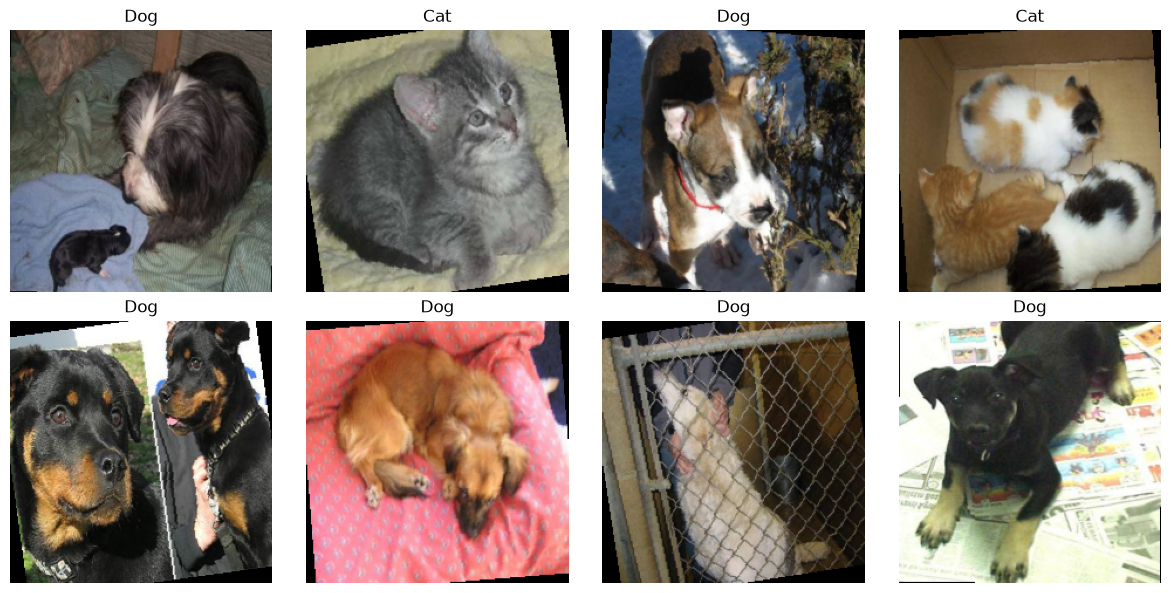

In [12]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    ax.imshow(image)
    ax.set_title("Cat" if labels[i] == 0 else "Dog")
    ax.axis("off")

plt.tight_layout()
plt.show()

## CNN Model

In [13]:
import torch.nn as nn

In [14]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            #input 3 x 224 x 224
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 32 x 112 x 122
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 64 X 56 x 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          

            # 128 x 28 x 28
            nn.AdaptiveAvgPool2d((4,4))
            # 128 x 4 x 4
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # 128 × 4 × 4 = 2048
            nn.Linear(128*4*4, 128),
            nn.ReLU(),

            nn.Dropout(.5),

            # Binary classification
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [15]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CatDogCNN()
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

In [16]:
print(model)

total_params = sum(p.numel() for p in model.parameters())

print("Total parameters:", total_params)

CatDogCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)
Total parameters: 355649


## Model Training and Validation

In [23]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images = images.to(device , non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()


    model.eval()
    running_val_loss = 0

    with torch.no_grad():
         
        for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

    epoch_train_loss = running_train_loss/len(train_loader)
    epoch_val_loss = running_val_loss/len(val_loader)

    print(f" epoch: {epoch+1}/{epochs}, training loss = {epoch_train_loss} & validation loss = {epoch_val_loss}")

 epoch: 1/10, training loss = 0.37075478005142637 & validation loss = 0.3622771747410297
 epoch: 2/10, training loss = 0.35949334397483557 & validation loss = 0.35355746150016787
 epoch: 3/10, training loss = 0.35133267424929254 & validation loss = 0.3922491155564785
 epoch: 4/10, training loss = 0.3378650027627762 & validation loss = 0.3776550889015198
 epoch: 5/10, training loss = 0.3258148890714676 & validation loss = 0.32942532300949096
 epoch: 6/10, training loss = 0.3185750006582029 & validation loss = 0.3222489710897207
 epoch: 7/10, training loss = 0.31093140013111287 & validation loss = 0.33689192309975624
 epoch: 8/10, training loss = 0.3029155885925689 & validation loss = 0.33840260952711104
 epoch: 9/10, training loss = 0.291051573027818 & validation loss = 0.3013396870344877
 epoch: 10/10, training loss = 0.2825545536729094 & validation loss = 0.3120100736618042


In [24]:
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

torch.save(model.state_dict(), "../models/cat_dog_cnn.pt")

In [25]:
correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)
        predicted = (probabilities >= 0.5).long()
        predicted = predicted.squeeze(1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

accuracy = correct_labels / total_labels * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.08%


### Classification Metrics

In [26]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).long()
        predictions = predictions.squeeze(1)

        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.tolist())

print("Total predictions:", len(all_predictions))
print("Total labels:", len(all_labels))

Total predictions: 2500
Total labels: 2500


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)

print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")

Accuracy:  89.08%
Precision: 86.50%
Recall:    92.43%


### Confusion Matrix

[[1080  179]
 [  94 1147]]


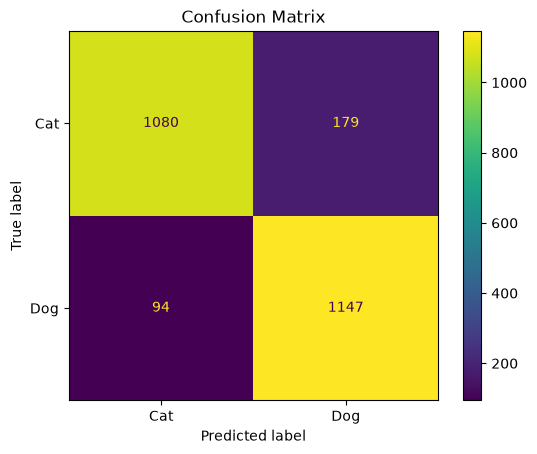

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

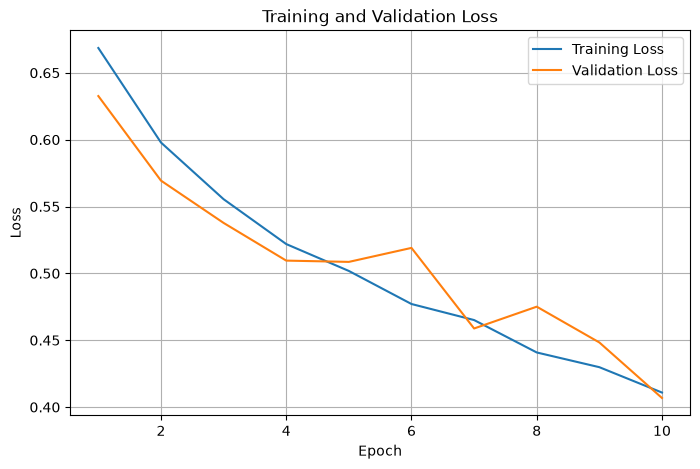

In [29]:
import matplotlib.pyplot as plt

epochs = range(1, 11)

train_losses = [
    0.668557,
    0.597861,
    0.555472,
    0.521922,
    0.501811,
    0.477088,
    0.465083,
    0.440847,
    0.429835,
    0.410864
]

val_losses = [
    0.632613,
    0.569374,
    0.537729,
    0.509544,
    0.508585,
    0.519051,
    0.458783,
    0.475093,
    0.448328,
    0.406794
]

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()